# Gradient descent for linear regression

We investigate gradient descent algorithms for training linear regression. The objective function we'll minimize is the least squares loss:
$$
\mbox{Loss}(w) = \frac{1}{N} \sum_{i=1}^N (w \cdot x - y)^2
$$

As we have mentioned before, least squares regression has an *analytical* (exact) solution that can be found using a little bit of matrix algebra:

$$
w = (X^T\cdot X)^{-1} \cdot X^T \cdot y
$$

So why would we use gradient descent when there is an exact solution that is easily computable? Two reasons:
* For pedagogical purposes, we'll just use the least squares objective to exemplify the gradient descent algorithm.
* In practice, the exact solution may be too computationally intensive to compute, for instance if we have a very large number of rows or columns in the feature matrix $X$. This is the reason why some of scikit-learn's various linear regression training algorithms (e.g. [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), [`Lasso`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) etc) are based on various types of optimization rather than using the exact solution.

This notebook is for illustrating gradient descent algorithms. For high-quality professional implementations of these models, of course you'd use scikit-learn or something else in practice.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg' 
plt.style.use('bmh')

As in Lecture 4, we'll define a superclass `LinearRegressor` that includes the functionality that is common for all types of linear regressors. In this case, the common part is just how we make predictions. We follow the scikit-learn convention and call the prediction function `predict`.

In [2]:
class LinearRegressor(object):        
    def predict(self, X):
        return X.dot(self.w)

We'll first implement stochastic gradient descent for this objective. (Specifically, SGD with a batch size of 1, meaning that we just consider one training instance at a time.) This is equivalent to the Widrow-Hoff algorithm that we discussed before.

In [3]:
class LeastSquaresRegressorSGD(LinearRegressor):

    def __init__(self, n_iter=10, eta=0.1):
        # we give the algorithm's hyperparameters as constructor inputs:
        # - the number of iterations through the training set
        # - the step length eta
        self.n_iter = n_iter
        self.eta = eta
        
    def fit(self, X, Y):
        
        # set n_instances = #rows of X and n_features = #columns of X
        n_instances, n_features = X.shape
        
        # initialize the weight vector to zero
        self.w = np.zeros( n_features )

        # for pedagogical purposes, we'll store the values of the objective function (summed 
        # over the whole training set) that we observed during training
        self.history = []

        # iterate a fixed number through the training set
        for i in range(self.n_iter):
            
            total_loss = 0
            
            # for each training instance (an input-output pair)
            for x, y in zip(X, Y):                            

                # compute the predicted value for this instance.
                g = x.dot(self.w)

                # how far off are we from the desired value?
                error = g - y
                
                total_loss += error**2 / n_instances
                
                # compute the gradient of the loss with respect to the weights
                # using just this instance
                gradient_w = 2*error*x / n_instances
                
                # update the weights based on the gradient
                self.w -= self.eta*gradient_w
            
            self.history.append(total_loss)
            
        print('SGD final loss: {:.4f}'.format(total_loss))
            

As a comparison, we will also implement a non-stochastic (i.e., use all of the instances in the training data) or batch gradient descent.

Here, we can look at the gradient to determine whether we are "close enough" to the optimum. We define "close enough" by a tolerance parameter: if the length of the gradient vector is below this tolerance, we terminate.

We'll use NumPy matrix and vector operations to express this more compactly. There is also a matter of computational efficiency: typically, writing your code using a few "large" operations will be more efficient than using many "small" operations.

In [4]:
class LeastSquaresRegressorGD(LinearRegressor):

    def __init__(self, n_iter=20, tolerance=1e-5, eta=0.1):
        self.n_iter = n_iter
        self.tolerance = tolerance
        self.eta = eta
        
    def fit(self, X, Y):

        n_instances, n_features = X.shape
        self.w = np.zeros(n_features)
        self.history = []
        
        for i in range(self.n_iter):            
            
            # predictions on the whole training set
            # this is a vector of predicted outputs
            G = X.dot(self.w)
            
            # vector of error values
            Error = G - Y

            # the loss value for the whole of the training set is the mean of the squared errors
            total_loss = np.mean(Error**2)

            # and the gradient is also computed over the whole training set, and the mean over the
            # individual gradients computed.
            gradient_w = np.mean(2*Error*X.T, axis=1)

            # if the gradient vector is small enough, terminate early
            if np.linalg.norm(gradient_w) <= self.tolerance:
                break
            
            # update the weights in the direction of reducing the error for the whole training set.            
            self.w -= self.eta*gradient_w
            
            self.history.append(total_loss)
            
        print('GD final loss (iteration {}): {:.4f}'.format(i+1, total_loss))

As a final variation, we'll also look at the intermediate point between the two extremes we saw before, where we use *minibatches*: subsets of the training set containing a few training instances.

Minibatch stochastic gradient descent is particularly common when training neural networks using GPUs. The GPUs carry out their computations in a highly parallelized manner, so we can compute the loss function for a number of training sample almost simultaneously. On the other hand, the GPU may not have a memory capacity large enough to hold the full training set. In this case, we can set a minibatch size so that we can fit a suitable number of training instances into the GPU memory.

The code is very similar to the full gradient descent we saw previously. The main difference is that we go through the training set, picking out a minibatch in each step.

In [5]:
class LeastSquaresRegressorSGDMinibatch(LinearRegressor):

    def __init__(self, n_iter=10, eta=0.1, batch_size=10):
        self.n_iter = n_iter
        self.eta = eta
        self.batch_size = batch_size
        
    def fit(self, X, Y):

        n_instances, n_features = X.shape
        self.w = np.zeros( n_features )

        self.history = []
        
        for i in range(self.n_iter):
            
            total_loss = 0
            
            # we go through the training set, picking self.batch_size instances in each step
            for batch_start in range(0, n_instances, self.batch_size):
                batch_end = batch_start + self.batch_size

                # take out the minibatch from the training set (X and Y parts separately)
                Xbatch = X[batch_start:batch_end, :]
                Ybatch = Y[batch_start:batch_end]
            
                # predictions for this batch
                G = Xbatch.dot(self.w)
                
                # errors in the batch
                Error = G - Ybatch

                # loss for this batch
                total_loss += np.sum(Error**2) / n_instances

                # gradient in this batch
                gradient_w = np.sum(2*Error*Xbatch.T, axis=1) / n_instances
                
                # update the weights in the direction of reducing the error for this minibatch.
                self.w -= self.eta*gradient_w
            
            self.history.append(total_loss)
        print('SGD-minibatch final loss: {:.4f}'.format(total_loss))

### Testing the training algorithms on a toy dataset

Make some toy synthetic data. This is the same dataset as we had in the notebook for lecture 4-1.

This is a univariate example, where there is just one input feature, so that it's easy to plot the data.

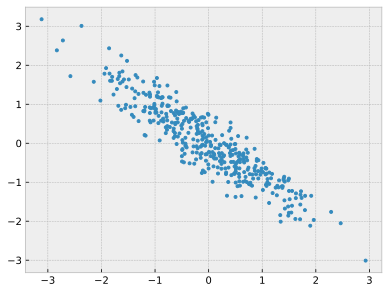

In [6]:
np.random.seed(0)

Xtrain = np.random.normal(size = (1000, 1))
Ytrain = -0.9 * Xtrain[:,0] + 0.4 * np.random.normal(size=Xtrain.shape[0])

Xtest = np.sort(np.random.normal(size = (400, 1)))
Ytest = -0.9 * Xtest[:,0] + 0.4 * np.random.normal(size=Xtest.shape[0])

plt.plot(Xtest, Ytest, '.');

We train linear regression models using the three variants of gradient descent defined above.

You can play around with how the learning rate affects the convergence of the algorithms. If it's too low, convergence will be slow. If it's too high, convergence may also be slow (because the algorithm "jumps around") or it may not converge at all.

In [7]:
from sklearn.metrics import mean_squared_error

gd_regression = LeastSquaresRegressorGD(n_iter=100, eta=0.5, tolerance=0.0001)
sgd_mb_regression = LeastSquaresRegressorSGDMinibatch(n_iter=10, eta=1.5, batch_size=100)
sgd_regression = LeastSquaresRegressorSGD(n_iter=10, eta=1.5)

gd_regression.fit(Xtrain, Ytrain)
sgd_mb_regression.fit(Xtrain, Ytrain)
sgd_regression.fit(Xtrain, Ytrain)


GD final loss (iteration 4): 0.1498
SGD-minibatch final loss: 0.1502
SGD final loss: 0.1502


We plot the development of the objective function, which we logged in the `history` list during training.

In this case, all the algorithms arrive near the optimum almost immediately. The full batch gradient descent algorithm performs poorly in its first iteration, but that is unsurprising since it hasn't actually made any updates by that point.

For other types of objective functions, there may be a more marked difference in the speed of convergence. SGD typically converges more quickly, although it may have some difficulty arriving exactly at the optimum. (As above, when we see that the full batch GD gives a slightly, slighly lower value than the two SGD variants.)

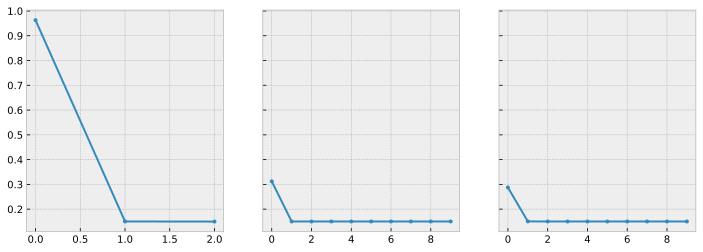

In [8]:
_, [a1, a2, a3] = plt.subplots(1, 3, figsize=(12,4), sharey=True) 
a1.plot(gd_regression.history, '.-')
a2.plot(sgd_mb_regression.history, '.-');
a3.plot(sgd_regression.history, '.-');

We also evaluate using MSE on the test set. The model found by the training algorithms are practically identical.

In [9]:
print(mean_squared_error(Ytest, gd_regression.predict(Xtest)))
print(mean_squared_error(Ytest, sgd_mb_regression.predict(Xtest)))
print(mean_squared_error(Ytest, sgd_regression.predict(Xtest)))

0.14454147962328961
0.14449212478367868
0.14451338064925456
